# Phase 2: Differential Expression Analysis

This notebook starts from the Phase 1 outputs and prefers the strict cleanup files (`exp_data_filtered_strict.pkl` and `metadata_strict.pkl`) when they exist. It then runs subtype-vs-normal DESeq2 analysis plus the DEG summary figures. The PyDESeq2 inference path is configured for a single worker to avoid joblib multiprocessing issues.


In [ ]:
import os
import warnings
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from pydeseq2.default_inference import DefaultInference
from pydeseq2 import utils as pydeseq2_utils

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

expr_candidates = [Path("exp_data_filtered_strict.pkl"), Path("exp_data_filtered.pkl")]
meta_candidates = [Path("metadata_strict.pkl"), Path("metadata.pkl")]
expr_path = next((path for path in expr_candidates if path.exists()), None)
meta_path = next((path for path in meta_candidates if path.exists()), None)
missing_inputs = []
if expr_path is None:
    missing_inputs.append("exp_data_filtered_strict.pkl or exp_data_filtered.pkl")
if meta_path is None:
    missing_inputs.append("metadata_strict.pkl or metadata.pkl")
if missing_inputs:
    raise FileNotFoundError(
        "Missing Phase 1 output files: " + ", ".join(missing_inputs) +
        ". Run phase1_preprocessing_qc.ipynb through the filtering steps first."
    )

# Prefer the strict cleanup outputs when available.
exp_raw = pd.read_pickle(expr_path)
metadata = pd.read_pickle(meta_path)
print(f"Using expression matrix: {expr_path.name}")
print(f"Using metadata table: {meta_path.name}")

class SerialInference(DefaultInference):
    def __init__(self):
        super().__init__(n_cpus=1, backend="loky")

    def lin_reg_mu(self, counts, size_factors, design_matrix, min_mu):
        mu_hat_ = np.array([
            pydeseq2_utils.fit_lin_mu(
                counts=counts[:, i],
                size_factors=size_factors,
                design_matrix=design_matrix,
                min_mu=min_mu,
            )
            for i in range(counts.shape[1])
        ])
        return mu_hat_.T

    def irls(self, counts, size_factors, design_matrix, disp, min_mu, beta_tol, min_beta=-30, max_beta=30, optimizer="L-BFGS-B", maxiter=250):
        res = [
            pydeseq2_utils.irls_solver(
                counts=counts[:, i],
                size_factors=size_factors,
                design_matrix=design_matrix,
                disp=disp[i],
                min_mu=min_mu,
                beta_tol=beta_tol,
                min_beta=min_beta,
                max_beta=max_beta,
                optimizer=optimizer,
                maxiter=maxiter,
            )
            for i in range(counts.shape[1])
        ]
        res = zip(*res, strict=False)
        mle_lfcs_, mu_hat_, hat_diagonals_, converged_ = (np.array(m) for m in res)
        return mle_lfcs_, mu_hat_.T, hat_diagonals_.T, converged_

    def alpha_mle(self, counts, design_matrix, mu, alpha_hat, min_disp, max_disp, prior_disp_var=None, cr_reg=True, prior_reg=False, optimizer="L-BFGS-B"):
        res = [
            pydeseq2_utils.fit_alpha_mle(
                counts=counts[:, i],
                design_matrix=design_matrix,
                mu=mu[:, i],
                alpha_hat=alpha_hat[i],
                min_disp=min_disp,
                max_disp=max_disp,
                prior_disp_var=prior_disp_var,
                cr_reg=cr_reg,
                prior_reg=prior_reg,
                optimizer=optimizer,
            )
            for i in range(counts.shape[1])
        ]
        res = zip(*res, strict=False)
        dispersions_, l_bfgs_b_converged_ = (np.array(m) for m in res)
        return dispersions_, l_bfgs_b_converged_

    def wald_test(self, design_matrix, disp, lfc, mu, ridge_factor, contrast, lfc_null, alt_hypothesis=None):
        num_genes = mu.shape[1]
        res = [
            pydeseq2_utils.wald_test(
                design_matrix=design_matrix,
                disp=disp[i],
                lfc=lfc[i],
                mu=mu[:, i],
                ridge_factor=ridge_factor,
                contrast=contrast,
                lfc_null=lfc_null,
                alt_hypothesis=alt_hypothesis,
            )
            for i in range(num_genes)
        ]
        res = zip(*res, strict=False)
        pvals, stats, se = (np.array(m) for m in res)
        return pvals, stats, se

    def lfc_shrink_nbinom_glm(self, design_matrix, counts, size, offset, prior_no_shrink_scale, prior_scale, optimizer, shrink_index):
        num_genes = counts.shape[1]
        res = [
            pydeseq2_utils.nbinomGLM(
                design_matrix=design_matrix,
                counts=counts[:, i],
                size=size[i],
                offset=offset,
                prior_no_shrink_scale=prior_no_shrink_scale,
                prior_scale=prior_scale,
                optimizer=optimizer,
                shrink_index=shrink_index,
            )
            for i in range(num_genes)
        ]
        res = zip(*res, strict=False)
        lfcs, inv_hessians, l_bfgs_b_converged_ = (np.array(m) for m in res)
        return lfcs, inv_hessians, l_bfgs_b_converged_

# Use a serial inference backend so PyDESeq2 runs reliably in sandboxed environments.
PYDESEQ_INFERENCE = SerialInference()

# Deduplicate gene names by keeping the row with the highest mean expression.
exp_raw["_mean"] = exp_raw.mean(axis=1, numeric_only=True)
exp = (
    exp_raw.reset_index()
    .sort_values("_mean", ascending=False)
    .drop_duplicates(subset="gene_name", keep="first")
    .drop(columns=["_mean"])
    .set_index("gene_name")
)

SUBTYPE_COLORS = {
    "LumA": "#1f77b4",
    "LumB": "#ff7f0e",
    "Basal": "#d62728",
    "Her2": "#9467bd",
    "Normal": "#2ca02c",
}
SUBTYPE_ORDER = ["Basal", "Her2", "LumA", "LumB", "Normal"]

# Recreate the visualization matrices used by the downstream DEG figures.
cpm = exp.div(exp.sum(axis=0), axis=1) * 1e6
log2_cpm = np.log2(cpm + 1)

sorted_meta = metadata.loc[exp.columns].copy()
sorted_meta["subtype"] = pd.Categorical(
    sorted_meta["subtype"], categories=SUBTYPE_ORDER, ordered=True
)
sorted_meta = sorted_meta.sort_values("subtype")
sorted_ids = sorted_meta.index.tolist()


In [10]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

LFC_THRESH = 1.5
PADJ_THRESH = 0.01

tumor_subtypes = ["Basal", "Her2", "LumA", "LumB"]
deg_results = {}  # subtype → DataFrame of DESeq2 results

for subtype in tumor_subtypes:
    print(f"\n{'='*60}")
    print(f"  Running DESeq2: {subtype} vs Normal")
    print(f"{'='*60}")

    # Subset to this subtype + Normal samples
    samples = metadata[metadata["subtype"].isin([subtype, "Normal"])].index
    counts_sub = exp[samples].T  # PyDESeq2 wants samples × genes
    counts_sub = counts_sub.astype(int)

    clinical_sub = metadata.loc[samples].copy()
    clinical_sub["condition"] = clinical_sub["subtype"].apply(lambda x: "Tumor" if x == subtype else "Normal")

    print(f"  Samples: {(clinical_sub['condition']=='Tumor').sum()} Tumor, "
          f"{(clinical_sub['condition']=='Normal').sum()} Normal")

    # Build DESeq2 dataset
    dds = DeseqDataSet(
        counts=counts_sub,
        metadata=clinical_sub,
        design="~condition",
        ref_level=["condition", "Normal"],
        inference=PYDESEQ_INFERENCE,
        quiet=True,
    )
    dds.deseq2()

    # Statistical testing
    stat_res = DeseqStats(dds, contrast=["condition", "Tumor", "Normal"], inference=PYDESEQ_INFERENCE, quiet=True)
    stat_res.summary()
    res_df = stat_res.results_df.copy()

    # Flag significant DEGs
    res_df["significant"] = (res_df["padj"] < PADJ_THRESH) & (res_df["log2FoldChange"].abs() > LFC_THRESH)
    n_up = ((res_df["significant"]) & (res_df["log2FoldChange"] > 0)).sum()
    n_down = ((res_df["significant"]) & (res_df["log2FoldChange"] < 0)).sum()

    print(f"  DEGs: {n_up} up, {n_down} down ({n_up + n_down} total)")

    deg_results[subtype] = res_df

print("\nAll comparisons complete.")



  Running DESeq2: Basal vs Normal
  Samples: 181 Tumor, 134 Normal
  DEGs: 3681 up, 2813 down (6494 total)

  Running DESeq2: Her2 vs Normal
  Samples: 77 Tumor, 134 Normal
  DEGs: 2686 up, 3562 down (6248 total)

  Running DESeq2: LumA vs Normal
  Samples: 528 Tumor, 134 Normal
  DEGs: 1736 up, 2705 down (4441 total)

  Running DESeq2: LumB vs Normal
  Samples: 198 Tumor, 134 Normal
  DEGs: 2450 up, 4103 down (6553 total)

All comparisons complete.


### 2.1 Volcano Plots

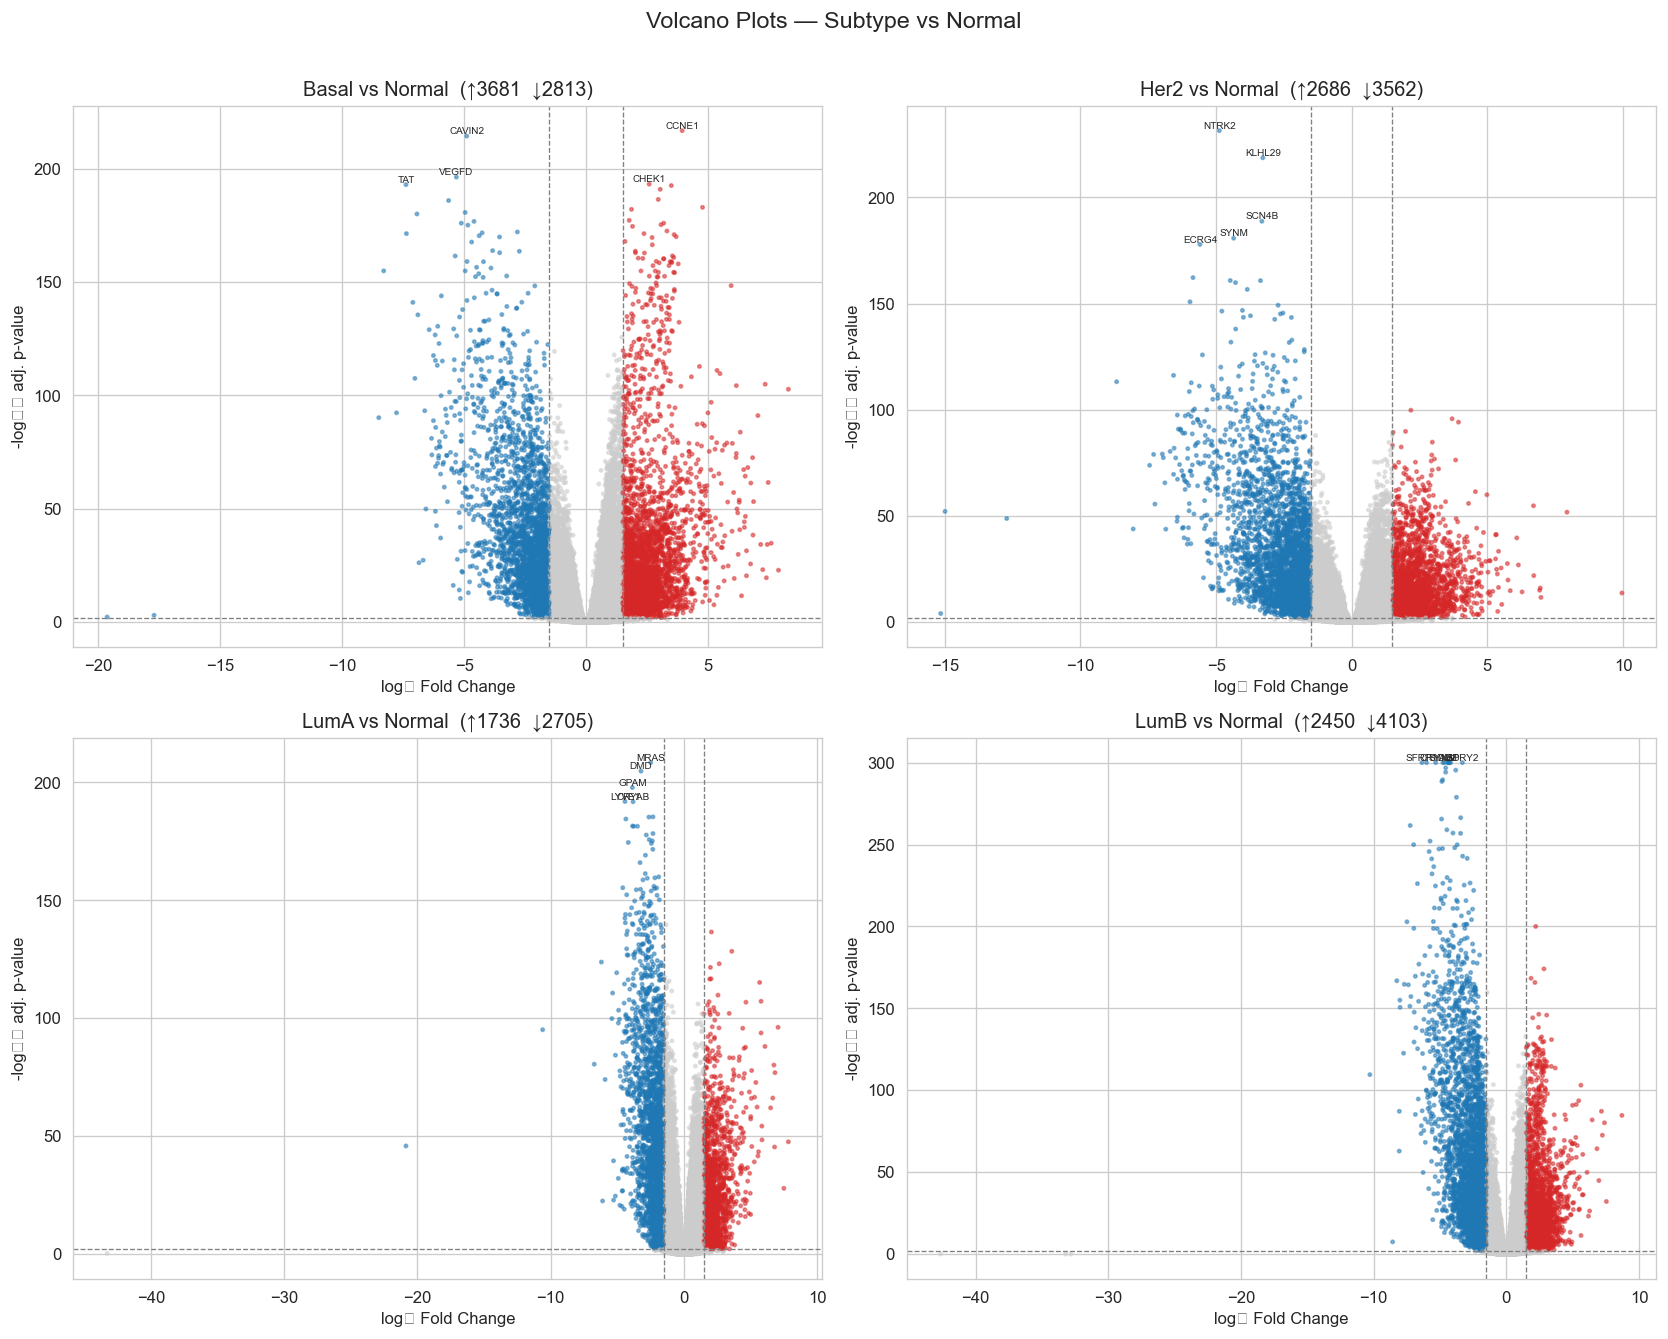

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for ax, subtype in zip(axes.flatten(), tumor_subtypes):
    df = deg_results[subtype].dropna(subset=["padj", "log2FoldChange"]).copy()
    df["-log10padj"] = -np.log10(df["padj"].clip(lower=1e-300))

    # Color: grey=NS, blue=down, red=up
    colors = np.where(
        df["significant"] & (df["log2FoldChange"] > 0), "#d62728",
        np.where(df["significant"] & (df["log2FoldChange"] < 0), "#1f77b4", "#cccccc")
    )

    ax.scatter(df["log2FoldChange"], df["-log10padj"], c=colors, s=4, alpha=0.5)
    ax.axhline(-np.log10(PADJ_THRESH), color="grey", ls="--", lw=0.8)
    ax.axvline(-LFC_THRESH, color="grey", ls="--", lw=0.8)
    ax.axvline(LFC_THRESH, color="grey", ls="--", lw=0.8)

    n_up = ((df["significant"]) & (df["log2FoldChange"] > 0)).sum()
    n_down = ((df["significant"]) & (df["log2FoldChange"] < 0)).sum()
    ax.set_title(f"{subtype} vs Normal  (↑{n_up}  ↓{n_down})", fontsize=12)
    ax.set_xlabel("log₂ Fold Change")
    ax.set_ylabel("-log₁₀ adj. p-value")

    # Label top 5 DEGs by significance
    top_genes = df.loc[df["significant"]].nlargest(5, "-log10padj")
    for _, row in top_genes.iterrows():
        ax.annotate(row.name, (row["log2FoldChange"], row["-log10padj"]),
                    fontsize=6, ha="center", va="bottom")

plt.suptitle("Volcano Plots — Subtype vs Normal", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/volcano_plots.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 DEG Summary Table

In [13]:
# Summary table
summary_rows = []
for subtype in tumor_subtypes:
    df = deg_results[subtype]
    sig = df[df["significant"]]
    summary_rows.append({
        "Subtype": subtype,
        "Total Genes Tested": len(df),
        "DEGs (up)": (sig["log2FoldChange"] > 0).sum(),
        "DEGs (down)": (sig["log2FoldChange"] < 0).sum(),
        "DEGs (total)": len(sig),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Subtype")
print(summary_df.to_string())

# Save individual DEG lists
for subtype in tumor_subtypes:
    sig = deg_results[subtype][deg_results[subtype]["significant"]].sort_values("padj")
    sig.to_csv(f"results/DEGs_{subtype}_vs_Normal.csv")

print(f"\nDEG lists saved to results/ directory.")

         Total Genes Tested  DEGs (up)  DEGs (down)  DEGs (total)
Subtype                                                          
Basal                 41556       3681         2813          6494
Her2                  41556       2686         3562          6248
LumA                  41556       1736         2705          4441
LumB                  41556       2450         4103          6553

DEG lists saved to results/ directory.


### 2.3 Heatmap of Top DEGs Across All Subtypes

We take the union of the top 25 DEGs (by adjusted p-value) from each subtype comparison and visualize their log₂-CPM expression across all samples.

Union of top DEGs: 85 genes


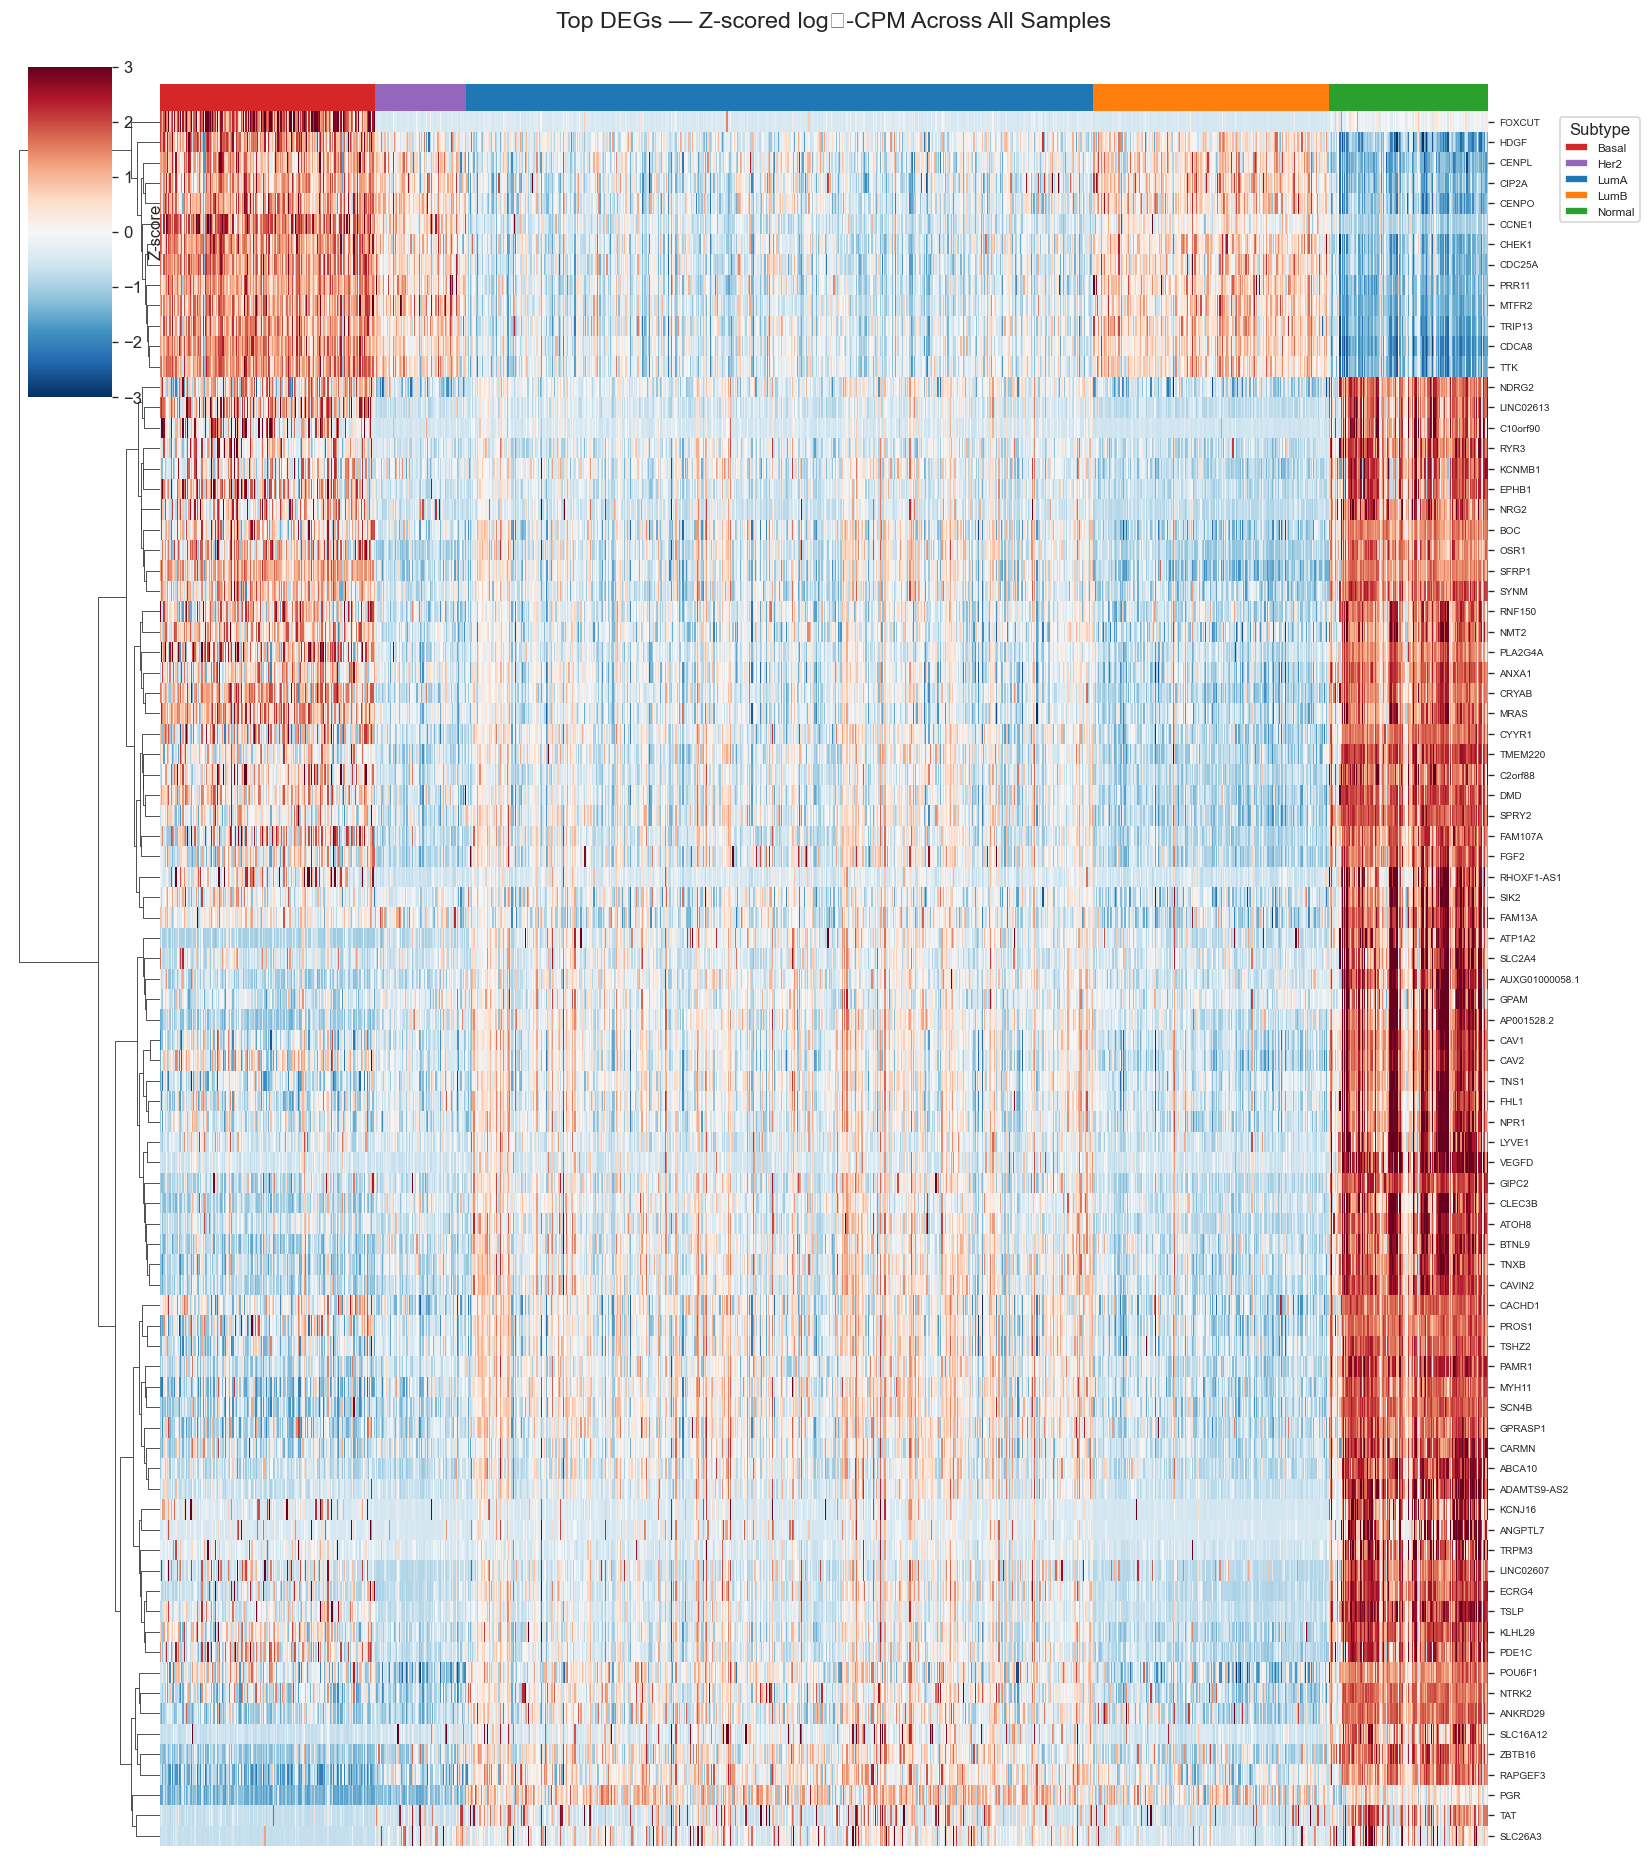

In [14]:
# Collect top 25 significant DEGs per subtype
top_genes_set = set()
for subtype in tumor_subtypes:
    sig = deg_results[subtype][deg_results[subtype]["significant"]].sort_values("padj")
    top_genes_set.update(sig.head(25).index)

top_genes = sorted(top_genes_set)
print(f"Union of top DEGs: {len(top_genes)} genes")

# Z-score normalized log2-CPM for heatmap
heatmap_data = log2_cpm.loc[log2_cpm.index.isin(top_genes), sorted_ids]
heatmap_z = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(heatmap_data.std(axis=1), axis=0)

col_colors = sorted_meta["subtype"].map(SUBTYPE_COLORS)

g = sns.clustermap(
    heatmap_z, col_cluster=False, row_cluster=True, method="ward",
    cmap="RdBu_r", vmin=-3, vmax=3, figsize=(14, max(8, len(top_genes) * 0.18)),
    col_colors=col_colors.values, xticklabels=False,
    yticklabels=True, cbar_kws={"label": "Z-score"},
    dendrogram_ratio=(0.1, 0.02), colors_ratio=0.015,
)
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.tick_params(axis="y", labelsize=6)
g.fig.suptitle("Top DEGs — Z-scored log₂-CPM Across All Samples", y=1.01, fontsize=14)
legend_handles = [Patch(facecolor=SUBTYPE_COLORS[s], label=s) for s in SUBTYPE_ORDER]
g.ax_heatmap.legend(handles=legend_handles, title="Subtype", loc="upper left",
                    bbox_to_anchor=(1.05, 1.0), frameon=True, fontsize=7)
plt.savefig("figures/top_degs_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Subtype-Specific vs Shared DEGs (UpSet-style summary)

In [15]:
# Venn-style summary: how many DEGs are unique to each subtype vs shared?
deg_sets = {}
for subtype in tumor_subtypes:
    deg_sets[subtype] = set(deg_results[subtype][deg_results[subtype]["significant"]].index)

# Build membership matrix
all_degs = sorted(set.union(*deg_sets.values()))
membership = pd.DataFrame(
    {st: [g in deg_sets[st] for g in all_degs] for st in tumor_subtypes},
    index=all_degs
)

# Count genes unique to each subtype and shared across all
for st in tumor_subtypes:
    unique = membership[membership[st] & ~membership.drop(columns=st).any(axis=1)]
    print(f"{st}-specific DEGs: {len(unique)}")

shared_all = membership[membership.all(axis=1)]
print(f"\nShared across ALL 4 subtypes: {len(shared_all)}")
print(f"Total unique DEGs (union): {len(all_degs)}")

# Save full DEG results (all genes, not just significant) for Phase 3
for subtype in tumor_subtypes:
    deg_results[subtype].to_csv(f"results/DESeq2_full_{subtype}_vs_Normal.csv")
print("\nFull DESeq2 results saved to results/ directory.")

Basal-specific DEGs: 2477
Her2-specific DEGs: 1158
LumA-specific DEGs: 286
LumB-specific DEGs: 963

Shared across ALL 4 subtypes: 1561
Total unique DEGs (union): 11536

Full DESeq2 results saved to results/ directory.
